## 1. Install & Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

print('All libraries imported successfully!')
import sklearn
print(sklearn.__version__)

All libraries imported successfully!
1.6.1


## 2. Load Your Dataset

In [22]:
CSV_PATH='people_count.csv'
TARGET_COLUMN = 'people_count'

df = pd.read_csv(CSV_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5571, 5)


,count_id,menu_id,timing,people_total,day_type_id
0,47,15,2026-04-16 16:34:42.967143+05:30,4,1
1,48,15,2026-04-16 16:36:53.345805+05:30,8,1
2,49,15,2026-04-16 16:38:43.740259+05:30,11,1
3,50,15,2026-04-16 16:40:44.01254+05:30,24,1
4,51,15,2026-04-16 16:42:44.408007+05:30,34,1


## 3. Preprocessing

In [23]:
df['timing'] = pd.to_datetime(df['timing'],utc=True)
df['timing_ist'] = df['timing'].dt.tz_convert('Asia/Kolkata')
df['hour']        = df['timing_ist'].dt.hour
df['minute']      = df['timing_ist'].dt.minute
df['day_of_week'] = df['timing_ist'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
def assign_slot(hour, minute):
    t = hour + minute / 60  # decimal hour
    if  7.00 <= t < 10.25:  return 'Breakfast'
    elif 12.00 <= t < 14.50: return 'Lunch'
    elif 16.00 <= t < 18.25: return 'Snacks'
    elif 19.00 <= t < 21.25: return 'Dinner'
    else:                    return 'out_of_slot'

df['meal_slot'] = df.apply(lambda r: assign_slot(r['hour'], r['minute']), axis=1)
df_clean = df[df['meal_slot'] != 'out_of_slot'].copy()
df_clean = df_clean.drop(columns=['count_id', 'menu_id', 'timing', 'timing_ist'])
df_clean['day_type_id'] = df_clean['day_type_id'].map({1: 0, 4: 1})

#One hot encode the meal_slot and day_of_the_week
df_clean = pd.get_dummies(df_clean, columns=['meal_slot', 'day_of_week'], drop_first=False)
# df_clean
X = df_clean.drop(columns=['people_total'])
y = df_clean['people_total']


In [24]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 3232 | Test size: 808


## 4. Train & Compare All Models

In [25]:
models = {
    'Linear Regression':        LinearRegression(),
    'Ridge':                    Ridge(alpha=1.0),
    'Lasso':                    Lasso(alpha=0.1),
    'ElasticNet':               ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree':            DecisionTreeRegressor(random_state=42),
    'Random Forest':            RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees':              ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':                  XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'K-Nearest Neighbors':      KNeighborsRegressor(n_neighbors=5),
    'SVR':                      SVR(kernel='rbf'),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    test_r2 = r2_score(y_test, y_pred)

    # 5-fold cross-validation R²
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results.append({
        'Model':       name,
        'Test R²':     round(test_r2, 4),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)':  round(cv_scores.std(), 4),
    })
    print(f'{name:30s} → Test R²: {test_r2:.4f} | CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False).reset_index(drop=True)
print()
print('=== Ranked Results ===')
results_df

Linear Regression              → Test R²: 0.4542 | CV R²: 0.4692 ± 0.0266
Ridge                          → Test R²: 0.4535 | CV R²: 0.4691 ± 0.0260
Lasso                          → Test R²: 0.4513 | CV R²: 0.4683 ± 0.0244
ElasticNet                     → Test R²: 0.3400 | CV R²: 0.3706 ± 0.0122
Decision Tree                  → Test R²: 0.2148 | CV R²: 0.3493 ± 0.0646
Random Forest                  → Test R²: 0.4483 | CV R²: 0.5430 ± 0.0568
Extra Trees                    → Test R²: 0.3074 | CV R²: 0.4379 ± 0.0679
Gradient Boosting              → Test R²: 0.6092 | CV R²: 0.6295 ± 0.0092
XGBoost                        → Test R²: 0.5896 | CV R²: 0.6030 ± 0.0532
K-Nearest Neighbors            → Test R²: 0.6038 | CV R²: 0.6244 ± 0.0463
SVR                            → Test R²: 0.2608 | CV R²: 0.2894 ± 0.0160

=== Ranked Results ===


,Model,Test R²,CV R² (mean),CV R² (std)
0,Gradient Boosting,0.6092,0.6295,0.0092
1,K-Nearest Neighbors,0.6038,0.6244,0.0463
2,XGBoost,0.5896,0.6030,0.0532
3,Linear Regression,0.4542,0.4692,0.0266
4,Ridge,0.4535,0.4691,0.0260
5,Lasso,0.4513,0.4683,0.0244
6,Random Forest,0.4483,0.5430,0.0568
7,ElasticNet,0.3400,0.3706,0.0122
8,Extra Trees,0.3074,0.4379,0.0679
9,SVR,0.2608,0.2894,0.0160


## 5. Visualise the Comparison

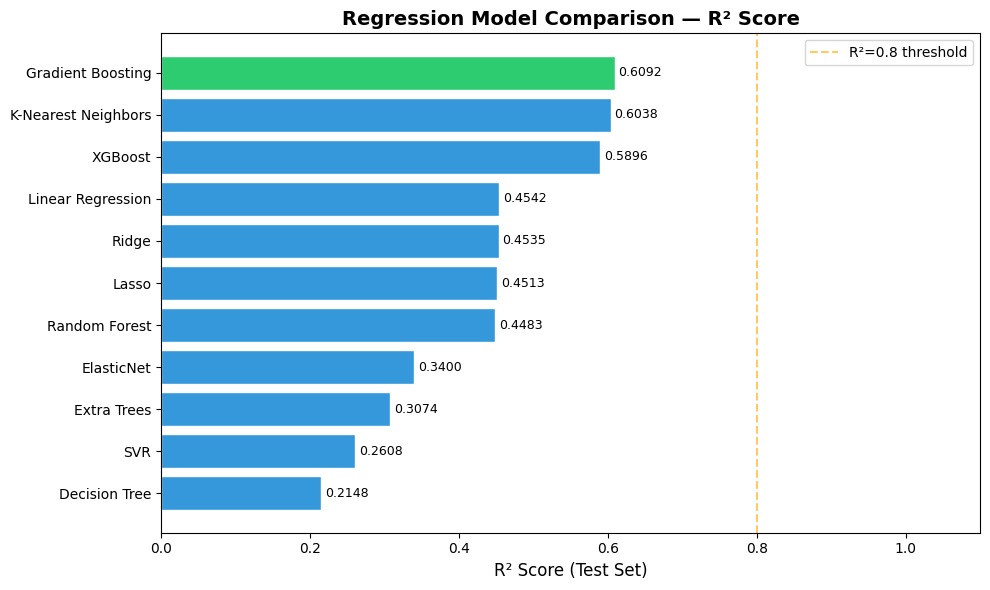

Chart saved as model_comparison.png


In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if r == results_df['Test R²'].max() else '#3498db' for r in results_df['Test R²']]

bars = ax.barh(results_df['Model'], results_df['Test R²'], color=colors, edgecolor='white')

for bar, val in zip(bars, results_df['Test R²']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('R² Score (Test Set)', fontsize=12)
ax.set_title('Regression Model Comparison — R² Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
ax.axvline(x=0.8, color='orange', linestyle='--', alpha=0.6, label='R²=0.8 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Chart saved as model_comparison.png')

## 6. Actual vs Predicted — Best Model

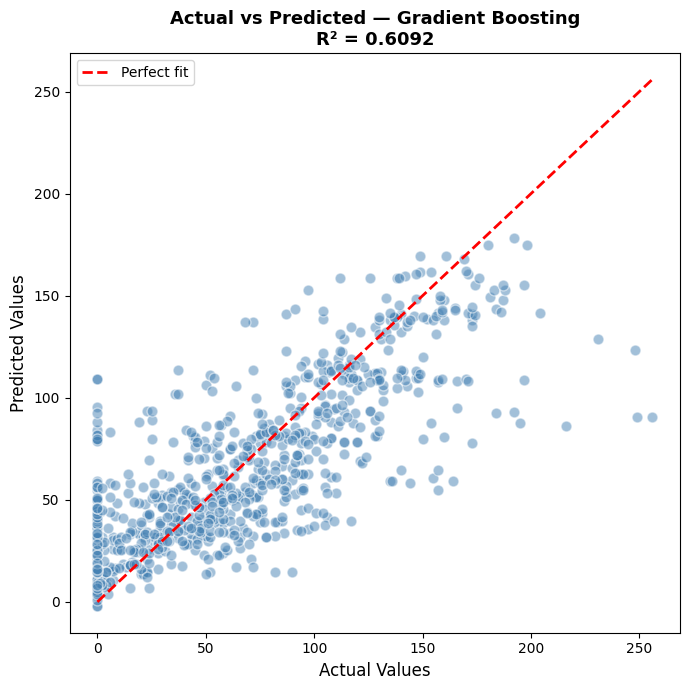


Best Model: Gradient Boosting with R² = 0.6092


In [27]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]
best_r2         = results_df.iloc[0]['Test R²']

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolors='white', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title(f'Actual vs Predicted — {best_model_name}\nR² = {best_r2:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nBest Model: {best_model_name} with R² = {best_r2:.4f}')

## 7. Feature Importance

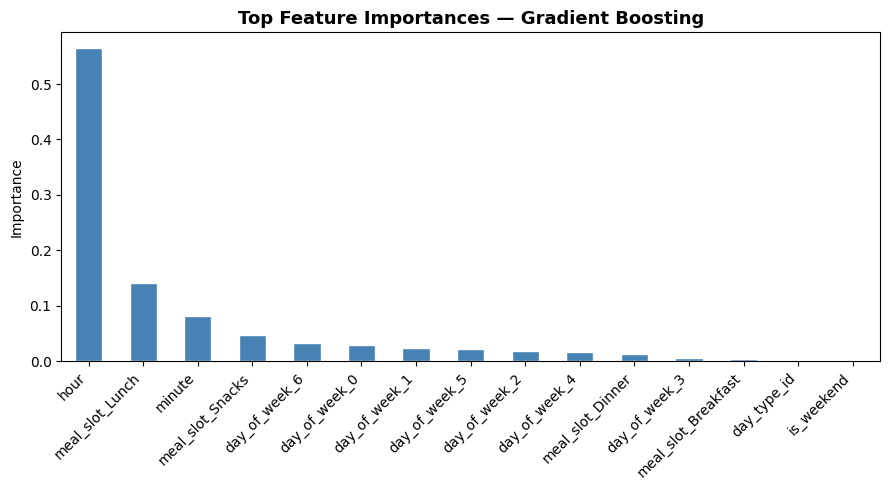

In [28]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    importances.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title(f'Top Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_), index=X.columns)
    coefs = coefs.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    coefs.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title(f'Top Feature Coefficients (abs) — {best_model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('|Coefficient|')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not expose feature importances directly.')

## 8. Saving the best model for deployment

In [29]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler,     'scaler.pkl')

# Also save the feature column names — important for inference!
joblib.dump(list(X.columns), 'feature_columns.pkl')

print(f'Saved model.pkl       → {best_model_name}')
print(f'Saved scaler.pkl      → StandardScaler')
print(f'Saved feature_columns.pkl → {list(X.columns)}')
print()
print('These 3 files are all you need for deployment!')

Saved model.pkl       → Gradient Boosting
Saved scaler.pkl      → StandardScaler
Saved feature_columns.pkl → ['day_type_id', 'hour', 'minute', 'is_weekend', 'meal_slot_Breakfast', 'meal_slot_Dinner', 'meal_slot_Lunch', 'meal_slot_Snacks', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']

These 3 files are all you need for deployment!


## 9. Trying Improvement


In [31]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2',
    verbose=1,        # shows progress while running
    n_jobs=-1         # uses all CPU cores to speed it up
)

grid.fit(X_train_scaled, y_train)

# Results
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"Best Params : {grid.best_params_}")
print(f"CV R²       : {grid.best_score_:.4f}")
print(f"Test R²     : {tuned_r2:.4f}")
print(f"Improvement : +{tuned_r2 - 0.6092:.4f} over default")

# Save the tuned model (overwrites the previous model.pkl)
joblib.dump(best_model, 'model.pkl')
print("\nTuned model saved to model.pkl ✅")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
CV R²       : 0.6828
Test R²     : 0.6613
Improvement : +0.0521 over default

Tuned model saved to model.pkl ✅
